In [70]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal



In [71]:
class quadratic_state(TypedDict):
    a: int
    b: int
    c: int
    D: float
    result: str
    eqn : str



In [72]:
def calc_determinant(state: quadratic_state):
    determinant=state['b']**2-4*state['a']*state['c']

    return {"D":determinant}


In [73]:
def check_condition(state: quadratic_state)-> Literal["real_roots","real_and_equal_roots","imaginary_roots"]:
    determinant= state['D']

    if determinant >0:
        return "real_roots"
    elif determinant <0:
        return "imaginary_roots"
    elif determinant == 0:
        return "real_and_equal_roots"

In [74]:
def real_roots(state: quadratic_state):

    x1= (-state['b'] + state['D']**0.5)/2*state['a']
    x2= (-state['b'] - state['D']**0.5)/2*state['a']

    result= f" Real Roots are {x1} and {x2}"

    return {"result":result}

In [75]:
def real_and_equal_roots(state: quadratic_state):

    x = -state['b']/2*state['a']

    result= f" Real and Equal Roots are {x}"

    return {"result":result}


In [76]:
def imaginary_roots(state: quadratic_state):

    result= f"No real Roots"

    return {"result":result}

In [77]:
graph = StateGraph(quadratic_state)


In [78]:
graph.add_node("calculate_determinant",calc_determinant)

graph.add_node("real_roots",real_roots)
graph.add_node("real_and_equal_roots",real_and_equal_roots)
graph.add_node("imaginary_roots",imaginary_roots)


In [79]:
graph.add_edge(START,"calculate_determinant")
graph.add_conditional_edges("calculate_determinant",check_condition)

In [80]:
graph.add_edge("real_roots",END)
graph.add_edge("real_and_equal_roots",END)
graph.add_edge("imaginary_roots",END)

In [81]:
workflow=graph.compile()

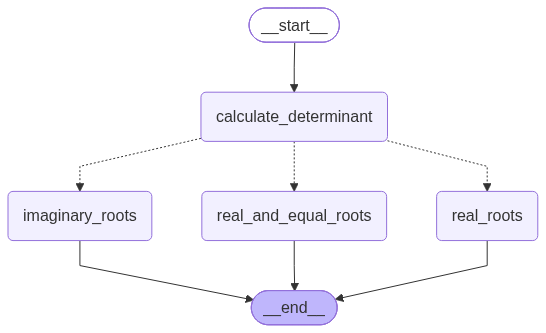

In [82]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [83]:
initial_state={
    "a":1,
    "b":2,
    "c":3,
}

In [84]:
result=workflow.invoke(initial_state)

In [85]:
result

{'a': 1, 'b': 2, 'c': 3, 'D': -8, 'result': 'No real Roots'}